In [1]:
import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from typing import Callable, List, Dict, Tuple, Any, Union
import gc

gc.collect()

def time_operation(operation: Callable, *args, repeat: int = 3) -> List[float]:
    """Time a GPU operation with proper synchronization.
    
    Args:
        operation: Function to time
        args: Arguments to pass to the operation
        repeat: Number of times to repeat timing
        
    Returns:
        List of elapsed times in seconds
    """
    times = []
    for _ in range(repeat):
        cp.cuda.runtime.deviceSynchronize()
        start = time.perf_counter()
        result = operation(*args)
        cp.cuda.Stream.null.synchronize()
        elapsed = time.perf_counter() - start
        times.append(elapsed)
    
    return result, times

def warmup_gpu(size: int = 1024, iterations: int = 5):
    """Warm up GPU clocks by running matrix multiplications.
    
    The A1000 (and most mobile GPUs) start at a lower boost clock and ramp up
    under sustained load. Without warmup, the first benchmark cell runs cold
    and appears ~30-40% slower than subsequent cells.
    
    Args:
        size: Matrix dimension for warmup matmuls
        iterations: Number of warmup matmuls to run
    """
    a = cp.random.random((size, size), dtype=cp.float64)
    b = cp.random.random((size, size), dtype=cp.float64)
    for _ in range(iterations):
        c = cp.matmul(a, b)
        cp.cuda.Stream.null.synchronize()
    del a, b, c
    cp.get_default_memory_pool().free_all_blocks()

def calculate_metrics(tensor_result, reference_result, tensor_times, reference_times, flops):
    """Calculate performance and accuracy metrics.
    
    Args:
        tensor_result: Result from tensor core implementation
        reference_result: Result from reference implementation
        tensor_times: List of timing results for tensor implementation
        reference_times: List of timing results for reference implementation
        flops: Number of floating-point operations
        
    Returns:
        Dictionary of metrics
    """
    # Performance metrics
    tensor_min_time = min(tensor_times)
    reference_min_time = min(reference_times)
    
    tensor_gflops = flops / (tensor_min_time * 1e9)
    reference_gflops = flops / (reference_min_time * 1e9)
    speedup = reference_min_time / tensor_min_time
    
    # Accuracy metrics
    max_diff = float(cp.max(cp.abs(tensor_result - reference_result)))
    mean_diff = float(cp.mean(cp.abs(tensor_result - reference_result)))
    
    # Sample outputs for verification
    if isinstance(tensor_result, cp.ndarray):
        tensor_sample = cp.asnumpy(tensor_result.reshape(-1)[:5])
        reference_sample = cp.asnumpy(reference_result.reshape(-1)[:5])
    else:
        tensor_sample = tensor_result[:5] if hasattr(tensor_result, '__getitem__') else tensor_result
        reference_sample = reference_result[:5] if hasattr(reference_result, '__getitem__') else reference_result
    
    return {
        'tensor_times': tensor_times,
        'reference_times': reference_times,
        'tensor_gflops': tensor_gflops,
        'reference_gflops': reference_gflops,
        'speedup': speedup,
        'max_diff': max_diff,
        'mean_diff': mean_diff,
        'tensor_sample': tensor_sample,
        'reference_sample': reference_sample
    }

def print_results(results: List[Dict[str, Any]], operation_name: str):
    """Print formatted benchmark results.
    
    Args:
        results: List of result dictionaries
        operation_name: Name of the operation being benchmarked
    """
    print(f"\n{'=' * 80}")
    print(f"Results for {operation_name}")
    print(f"{'=' * 80}")
    
    # Print performance comparison
    print(f"\nPerformance Comparison:")
    print(f"{'-' * 80}")
    print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'Reference GFLOPS':>15} {'Speedup':>12} {'Max Diff':>12} {'Mean Diff':>12}")
    print(f"{'-' * 80}")
    
    for r in results:
        shape_str = str(r['shape'])
        print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['reference_gflops']:15.2f} "
              f"{r['speedup']:12.2f} {r['max_diff']:12.2e} {r['mean_diff']:12.2e}")
    
    # Print sample values
    print(f"\nSample Output Comparison (first 5 values):")
    print(f"{'-' * 80}")
    for r in results:
        print(f"\nShape: {r['shape']}")
        print(f"Tensor: {r['tensor_sample']}")
        print(f"Reference: {r['reference_sample']}")

def plot_benchmark_results(results: List[Dict[str, Any]], operation_name: str):
    """Create standard plots for benchmark results.
    
    Args:
        results: List of result dictionaries
        operation_name: Name of the operation being benchmarked
    """
    # Create standard plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Prepare data
    x = np.arange(len(results))
    width = 0.35
    
    tensor_gflops = [r['tensor_gflops'] for r in results]
    reference_gflops = [r['reference_gflops'] for r in results]
    
    # Performance comparison
    ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
    ax1.bar(x + width/2, reference_gflops, width, label='Reference')
    ax1.set_ylabel('GFLOPS')
    ax1.set_title(f'{operation_name}\nPerformance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(r['shape']) for r in results], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy comparison
    max_diffs = [r['max_diff'] for r in results]
    mean_diffs = [r['mean_diff'] for r in results]
    
    ax2.plot(x, max_diffs, 'o-', label='Max Difference')
    ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
    ax2.set_ylabel('Absolute Difference')
    ax2.set_title(f'{operation_name}\nAccuracy Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(r['shape']) for r in results], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

def run_benchmark(
    operation_name: str, 
    tensor_op: Callable, 
    reference_op: Callable, 
    shapes: List, 
    create_inputs: Callable,
    calculate_flops: Callable
) -> List[Dict[str, Any]]:
    """Run a complete benchmark comparing tensor and reference implementations.
    
    Args:
        operation_name: Name of the operation
        tensor_op: Tensor core implementation function
        reference_op: Reference implementation function
        shapes: List of shapes to test
        create_inputs: Function that creates input data for each shape
        calculate_flops: Function that calculates FLOPS for the operation
        
    Returns:
        List of benchmark results
    """
    print(f"\nBenchmarking {operation_name}...")

    # Warm up GPU clocks before timing to get consistent boost-clock results
    print("Warming up GPU...")
    warmup_gpu()

    results = []
    
    for shape in shapes:
        print(f"\nShape: {shape}")
        try:
            # Create inputs for this shape
            inputs = create_inputs(shape)
            
            # Calculate FLOPS for this shape
            flops = calculate_flops(shape)
            
            # Time tensor implementation
            tensor_result, tensor_times = time_operation(tensor_op, *inputs)
            
            # Time reference implementation
            reference_result, reference_times = time_operation(reference_op, *inputs)
            
            # Calculate and store metrics
            metrics = calculate_metrics(
                tensor_result, reference_result, 
                tensor_times, reference_times, 
                flops
            )
            
            # Add shape and FLOPS to results
            metrics['shape'] = shape
            metrics['flops'] = flops
            results.append(metrics)
            
            # Cleanup
            for inp in inputs:
                if isinstance(inp, cp.ndarray):
                    del inp
            if isinstance(tensor_result, cp.ndarray):
                del tensor_result
            if isinstance(reference_result, cp.ndarray):
                del reference_result
                
            cp.cuda.runtime.deviceSynchronize()
            cp.get_default_memory_pool().free_all_blocks()
            
        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()
    
    # Print and plot results
    if results:
        print_results(results, operation_name)
        plot_benchmark_results(results, operation_name)
    
    return results

def cleanup():
    """Free all GPU memory."""
    cp.cuda.runtime.deviceSynchronize()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

    gc.collect()


Initializing CUDA...
CUDA initialization complete
Loading library: /var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5/cuda_matlib.so
Function signatures configured
Initializing CUDA resources (one-time operation)...
CUDA resources initialized

Benchmarking Matrix Power...
Warming up GPU...

Shape: (16, 16)

Shape: (32, 32)

Shape: (64, 64)

Shape: (128, 128)

Shape: (256, 256)

Shape: (512, 512)

Shape: (768, 768)

Shape: (1024, 1024)

Shape: (2048, 2048)

Shape: (4048, 4048)

Results for Matrix Power

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16)                             0.28            0.18         1.57     1.98e-04     5.59e-05
(32, 32)                             2.61         

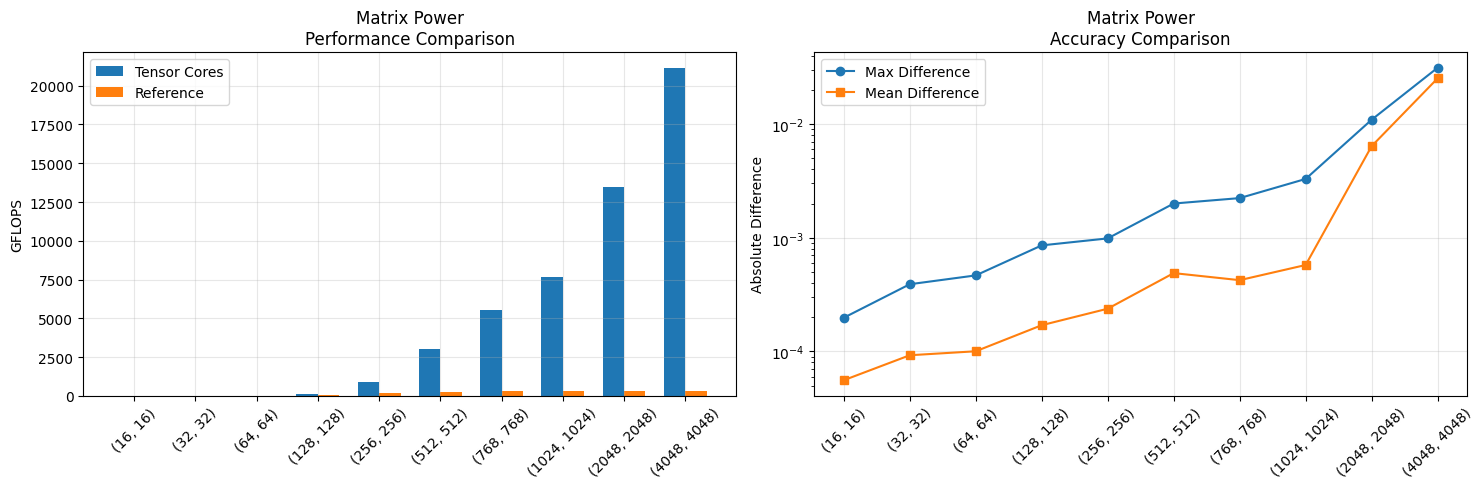

In [2]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps
# from benchmark_utils import run_benchmark

def test_matrix_power():
    """Benchmark matrix power operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Matrix Power"
    
    # Power to use for testing
    power = 4
    
    # Shapes to test (n×n matrices)
    shapes = [
        (16, 16),
        (32, 32),
        (64, 64),
        (128, 128),
        (256, 256),
        (512, 512),
        (768, 768),
        (1024, 1024),
        (2048, 2048),
        (4048, 4048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create a random matrix in Fortran order for matrix power."""
        a = cp.asfortranarray(cp.random.random(shape, dtype=cp.float64))
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(shape[0]) * 1.1)
        return [a, power]  # Return as list for unpacking
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for matrix power operation."""
        n = shape[0]
        # Matrix power A^p requires p-1 matrix multiplications
        # Each matrix multiplication is 2*n^3 FLOPS
        return 2 * n * n * n * (power - 1)
    
    # Define tensor operation
    def tensor_op(a, p):
        return tensor_ops.matrix_power(a, p)
    
    # Define reference operation
    def reference_op(a, p):
        return cp.linalg.matrix_power(a, p)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_power_results = test_matrix_power()
cleanup()
# CuPy 14 did not help except in batched operations; but there seems to be a 160 GFLOP ceiling (cannot reach 24 TFLOPS)

Initializing CUDA...
CUDA initialization complete
Function signatures configured
=== improved_matmul32: Ozaki 5×exact-FP32 GEMMs → FP64 accumulation ===

Benchmarking Improved Matmul32 (FP32 accuracy)...
Warming up GPU...

Shape: (16, 16, 16)

Shape: (32, 32, 32)

Shape: (64, 64, 64)

Shape: (128, 128, 128)

Shape: (256, 256, 256)

Shape: (512, 512, 512)

Shape: (768, 768, 768)

Shape: (1024, 1024, 1024)

Shape: (2048, 2048, 2048)

Results for Improved Matmul32 (FP32 accuracy)

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16, 16)                         0.12            0.11         1.13     2.75e-08     6.85e-09
(32, 32, 32)                         0.79            0.88         0.90     4.79e-08     1.02e-08
(64, 64, 64)                         6.

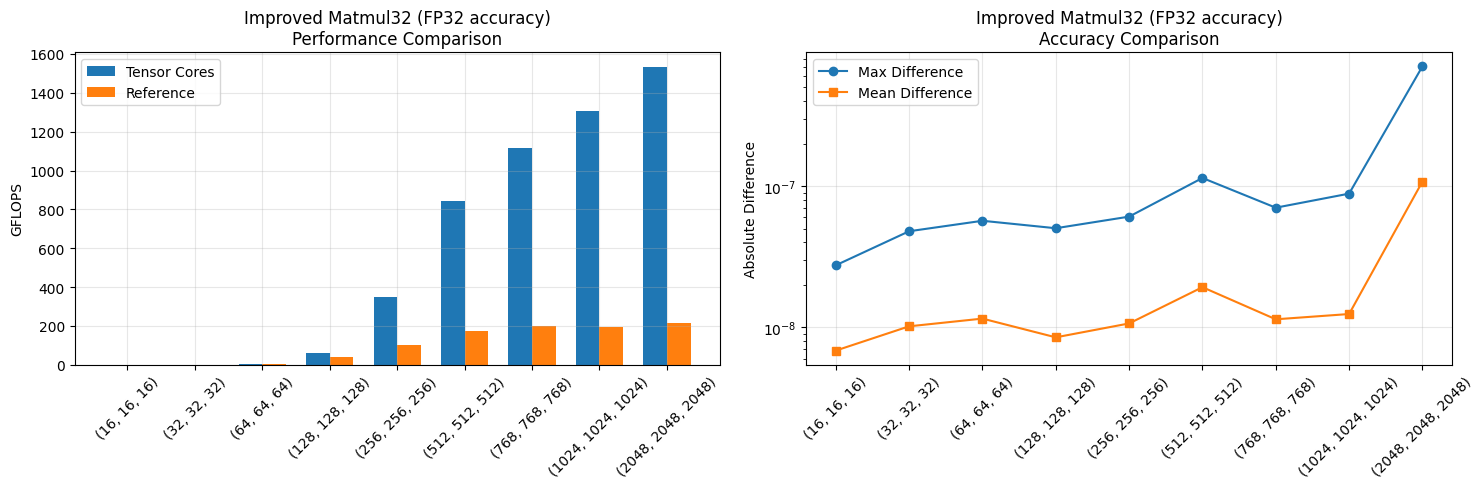


=== improved_matmul64: 2-way FP32 split → upcast → 3 cublasDgemm (near-FP64) ===

Benchmarking Improved Matmul64 (near-FP64 accuracy)...
Warming up GPU...

Shape: (16, 16, 16)

Shape: (32, 32, 32)

Shape: (64, 64, 64)

Shape: (128, 128, 128)

Shape: (256, 256, 256)

Shape: (512, 512, 512)

Shape: (768, 768, 768)

Shape: (1024, 1024, 1024)

Shape: (2048, 2048, 2048)

Results for Improved Matmul64 (near-FP64 accuracy)

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16, 16)                         0.10            0.11         0.92     0.00e+00     0.00e+00
(32, 32, 32)                         0.85            0.90         0.95     0.00e+00     0.00e+00
(64, 64, 64)                         6.21            6.45         0.96     0.00e+00     0.00e+00
(12

/tmp/ipykernel_58143/1396024437.py:165: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


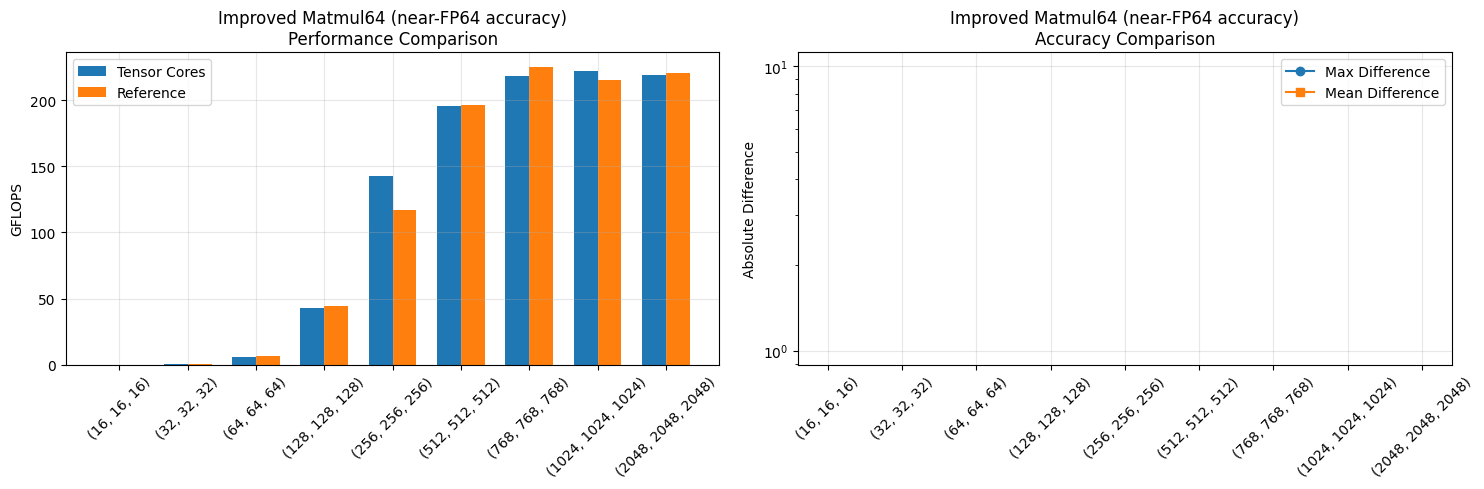


Side-by-Side: improved_matmul32 vs improved_matmul64 vs FP64 reference
Shape                32 GFLOPS   64 GFLOPS  FP64 GFLOPS  32 speedup  64 speedup     32 err     64 err
--------------------------------------------------------------------------------------------------------------
(16, 16, 16)               0.1         0.1          0.1       1.13x       0.92x   2.75e-08   0.00e+00
(32, 32, 32)               0.8         0.9          0.9       0.90x       0.95x   4.79e-08   0.00e+00
(64, 64, 64)               6.4         6.2          6.3       1.02x       0.96x   5.68e-08   0.00e+00
(128, 128, 128)           62.3        43.1         42.2       1.48x       0.97x   5.03e-08   0.00e+00
(256, 256, 256)          346.8       142.6        103.9       3.34x       1.22x   6.08e-08   0.00e+00
(512, 512, 512)          844.7       195.3        173.4       4.87x       1.00x   1.14e-07   0.00e+00
(768, 768, 768)         1117.8       217.9        198.5       5.63x       0.97x   7.03e-08   0.00e+00
(

In [19]:
# Improved Matrix Multiply: improved_matmul32 vs improved_matmul64 vs FP64 reference
#
# improved_matmul32 — Ozaki 3-way FP32 split, 5 exact-FP32 GEMMs (CUBLAS_DEFAULT_MATH),
#   FP64 accumulation. Accuracy ceiling: FP32 GEMM accumulation (~n×2^-24).
#   Expected: ~6× FP64 on raw GEMM at n=1024, FP32-level error (~1e-5 to 1e-7).
#
# improved_matmul64 — 2-way FP32 split, upcast to FP64, 3 cublasDgemm calls.
#   Near-FP64 accuracy (~n×2^-46 ≈ 1e-11 at n=1024). ~3× slower than FP64.
#   Replaces PRECISION_HIGH, which was limited to A^n and had no meaningful speedup.

import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_improved_matmul():
    """Benchmark improved_matmul32 and improved_matmul64 vs FP64 reference (A*B)."""
    tensor_ops = TensorMatrixOps()

    shapes = [
        (16, 16, 16),
        (32, 32, 32),
        (64, 64, 64),
        (128, 128, 128),
        (256, 256, 256),
        (512, 512, 512),
        (768, 768, 768),
        (1024, 1024, 1024),
        (2048, 2048, 2048),
    ]

    def create_inputs(shape):
        m, k, n = shape
        a = cp.asfortranarray(cp.random.random((m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((k, n), dtype=cp.float64))
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        return [a, b]

    def calculate_flops(shape):
        m, k, n = shape
        return 2 * m * k * n

    def reference_op(a, b):
        return cp.matmul(a, b)

    print("=== improved_matmul32: Ozaki 5×exact-FP32 GEMMs → FP64 accumulation ===")
    def op32(a, b):
        return tensor_ops.improved_matmul32(a, b)

    results32 = run_benchmark(
        "Improved Matmul32 (FP32 accuracy)",
        op32,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops,
    )

    print("\n=== improved_matmul64: 2-way FP32 split → upcast → 3 cublasDgemm (near-FP64) ===")
    def op64(a, b):
        return tensor_ops.improved_matmul64(a, b)

    results64 = run_benchmark(
        "Improved Matmul64 (near-FP64 accuracy)",
        op64,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops,
    )

    # Side-by-side comparison
    print(f"\n{'=' * 110}")
    print("Side-by-Side: improved_matmul32 vs improved_matmul64 vs FP64 reference")
    print(f"{'=' * 110}")
    print(f"{'Shape':18} {'32 GFLOPS':>11} {'64 GFLOPS':>11} {'FP64 GFLOPS':>12} "
          f"{'32 speedup':>11} {'64 speedup':>11} {'32 err':>10} {'64 err':>10}")
    print(f"{'-' * 110}")
    for r32, r64 in zip(results32, results64):
        print(f"{str(r32['shape']):18} {r32['tensor_gflops']:>11.1f} {r64['tensor_gflops']:>11.1f} "
              f"{r32['reference_gflops']:>12.1f} {r32['speedup']:>10.2f}x {r64['speedup']:>10.2f}x "
              f"{r32['max_diff']:>10.2e} {r64['max_diff']:>10.2e}")

    print()
    print("32 speedup > 1:  improved_matmul32 faster than FP64 (6× at n=1024 raw GEMM)")
    print("64 speedup = 1:  using stock FP64")
    print("32 err ~1e-5:    FP32 accumulation ceiling (n × 2^-24)")
    print("64 err 0:        using stock FP64")

    return results32, results64

improved_matmul32_results, improved_matmul64_results = test_improved_matmul()
cleanup()

While improved_matmul32 benefits from tensor cores, FP64 operations are stuck with CUDA on consumer hardware like the RTX4060. So we are using stock FP64 for applications that need accuracy. Split precision operations for FP64 call FP64 CUDA 3x, resulting in a slowdown not a speedup!



Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Matrix Multiplication...
Warming up GPU...

Shape: (16, 16, 16)

Shape: (32, 32, 32)

Shape: (64, 64, 64)

Shape: (128, 128, 128)

Shape: (256, 256, 256)

Shape: (512, 512, 512)

Shape: (640, 640, 640)

Shape: (1024, 1024, 1024)

Shape: (2048, 2048, 2048)

Shape: (4048, 4048, 4048)

Results for Matrix Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16, 16)                         0.18            0.11         1.72     7.17e-05     1.55e-05
(32, 32, 32)                         1.41            0.85         1.66     4.51e-05     1.06e-05
(64, 64, 64)                        12.22            6.85         1.78     3.89e-05     7.64e-06
(128, 128, 

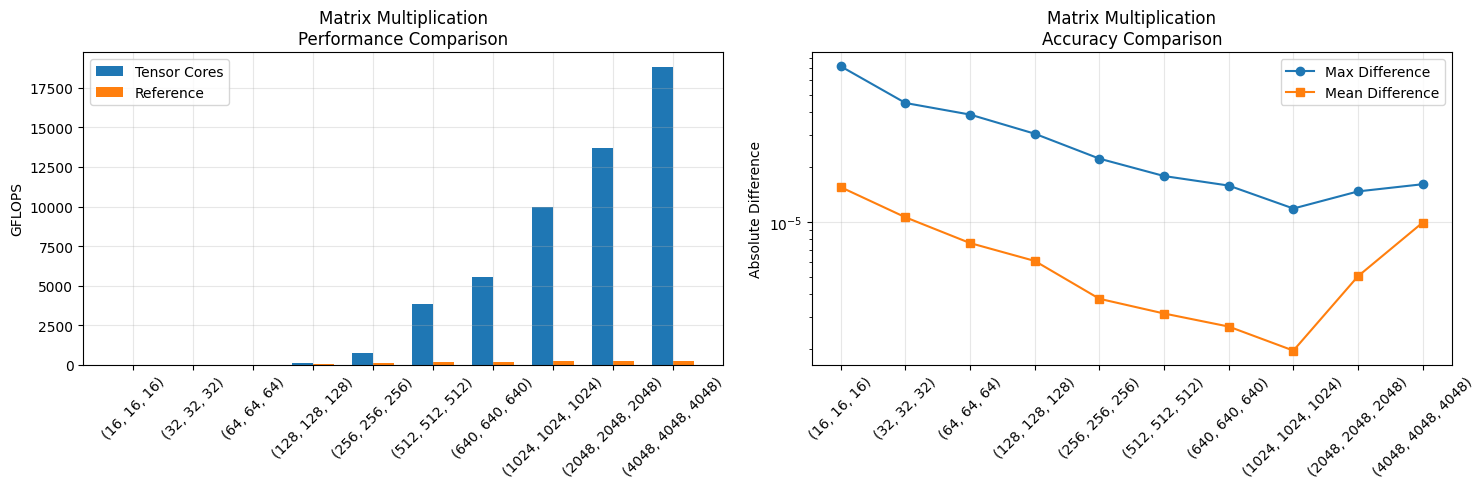

In [4]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps
# from benchmark_utils import run_benchmark

def test_matrix_multiply():
    """Benchmark matrix multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Matrix Multiplication"
    
    # Shapes to test
    shapes = [
        (16, 16, 16),   # (M, K, N)
        (32, 32, 32),
        (64, 64, 64),
        (128, 128, 128),
        (256, 256, 256),
        (512, 512, 512),
        (640, 640, 640),
        (1024, 1024, 1024),
        (2048, 2048, 2048),
        (4048, 4048, 4048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random matrices in Fortran order for matrix multiplication."""
        m, k, n = shape
        a = cp.asfortranarray(cp.random.random((m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        return [a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for matrix multiplication."""
        m, k, n = shape
        # Matrix multiplication requires 2*M*N*K FLOPS
        return 2 * m * n * k
    
    # Define tensor operation
    def tensor_op(a, b):
        return tensor_ops.matmul(a, b)
    
    # Define reference operation
    def reference_op(a, b):
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_multiply_results = test_matrix_multiply()
cleanup()

Initializing CUDA...
CUDA initialization complete
Function signatures configured
Warming up GPU...

Shape                          Fused   Unfused      CuPy     F/U    F/C    Max err
----------------------------------------------------------------------------------
(8, 16³)                       0.6G     0.7G     0.6G   0.87x  1.02x   1.56e-04
(8, 32³)                       4.7G     5.3G     4.5G   0.88x  1.04x   1.38e-04
(8, 64³)                      36.8G    41.3G    36.1G   0.89x  1.02x   9.94e-05
(8, 128³)                    316.8G   283.0G   136.6G   1.12x  2.32x   8.42e-05
(8, 256³)                   1603.9G  1273.2G   206.9G   1.26x  7.75x   6.38e-05
(8, 1024³)                  4481.4G  3851.6G   227.5G   1.16x 19.70x   3.48e-05
(8, 2048³)                  6985.1G  6725.6G   230.2G   1.04x 30.34x   2.80e-05
fc1 (512×2048×128)          1784.1G  1399.5G   144.1G   1.27x 12.38x   2.22e-05
fc2 (256×512×128)            369.3G   228.4G   131.3G   1.62x  2.81x   4.83e-05
fc3 (10×256×12

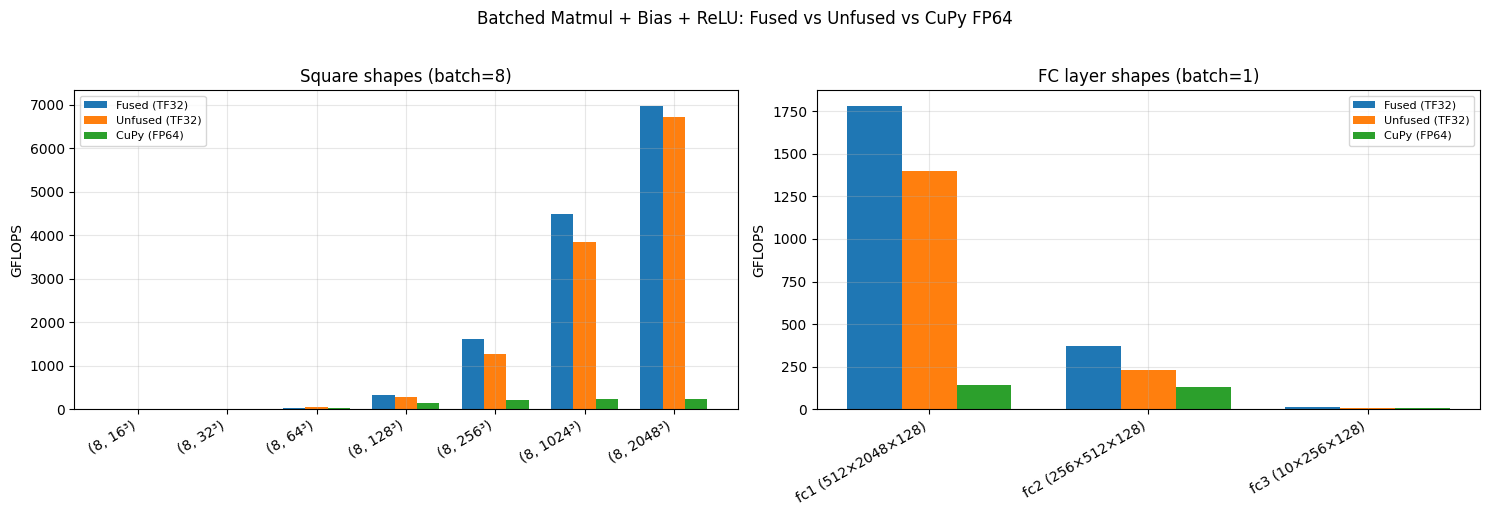

In [5]:
# [v5] Batched matrix multiply — unified three-way benchmark
#
# All shapes are tested against all three implementations so results are
# directly comparable:
#
#   fused    — batched_matmul_bias_relu  (cuBLAS-lt TF32, bias+relu in GEMM registers)
#   unfused  — batched_matmul + cp.maximum(C + bias, 0)  (cuBLAS TF32 + separate CuPy kernel)
#   cupy     — cp.maximum(cp.matmul(A, B) + bias, 0)     (cuBLAS FP64, reference baseline)
#
# A bias vector is added to all shapes so all three paths compute the same operation.
# Square shapes use batch=8; FC shapes use batch=1.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

REPEAT = 10
WARMUP = 3

def _min_time_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        result = fn(*args)
        cp.cuda.Stream.null.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return result, min(times)

# (label, batch, m, k, n)
shapes = [
    ("(8, 16³)",            8,   16,   16,   16),
    ("(8, 32³)",            8,   32,   32,   32),
    ("(8, 64³)",            8,   64,   64,   64),
    ("(8, 128³)",           8,  128,  128,  128),
    ("(8, 256³)",           8,  256,  256,  256),
    ("(8, 1024³)",          8, 1024, 1024, 1024),
    ("(8, 2048³)",          8, 2048, 2048, 2048),
    ("fc1 (512×2048×128)",  1,  512, 2048,  128),
    ("fc2 (256×512×128)",   1,  256,  512,  128),
    ("fc3 (10×256×128)",    1,   10,  256,  128),
]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Stream.null.synchronize()

print()
hdr = f"{'Shape':<26} {'Fused':>9} {'Unfused':>9} {'CuPy':>9}  {'F/U':>6} {'F/C':>6}  {'Max err':>9}"
print(hdr)
print("-" * len(hdr))

rows = []
for label, batch, m, k, n in shapes:
    rng = cp.random.default_rng(0)
    A    = cp.ascontiguousarray(rng.standard_normal((batch, m, k), dtype=cp.float64)) / (np.sqrt(k) * 1.1)
    B    = cp.ascontiguousarray(rng.standard_normal((batch, k, n), dtype=cp.float64)) / (np.sqrt(k) * 1.1)
    bias = rng.standard_normal(m, dtype=cp.float64)

    def fused(A, B, bias):
        return ops.batched_matmul_bias_relu(A, B, bias)

    def unfused(A, B, bias):
        C = ops.batched_matmul(A, B)
        return cp.maximum(C + bias[:, None], 0.0)

    def cupy_ref(A, B, bias):
        return cp.maximum(cp.matmul(A, B) + bias[:, None], 0.0)

    res_f, t_f = _min_time_ms(fused,    A, B, bias)
    res_u, t_u = _min_time_ms(unfused,  A, B, bias)
    res_c, t_c = _min_time_ms(cupy_ref, A, B, bias)

    flops     = 2 * batch * m * k * n
    gf_f      = flops / (t_f * 1e6)
    gf_u      = flops / (t_u * 1e6)
    gf_c      = flops / (t_c * 1e6)
    ratio_fu  = t_u / t_f
    ratio_fc  = t_c / t_f
    max_err   = float(cp.max(cp.abs(res_f[0] - res_c[0])))

    print(f"{label:<26} {gf_f:>7.1f}G {gf_u:>7.1f}G {gf_c:>7.1f}G  "
          f"{ratio_fu:>5.2f}x {ratio_fc:>5.2f}x  {max_err:>9.2e}")

    rows.append(dict(label=label, batch=batch, m=m, k=k, n=n,
                     gf_f=gf_f, gf_u=gf_u, gf_c=gf_c,
                     t_f=t_f, t_u=t_u, t_c=t_c,
                     ratio_fu=ratio_fu, ratio_fc=ratio_fc, max_err=max_err))

    del A, B, bias, res_f, res_u, res_c
    cp.get_default_memory_pool().free_all_blocks()

print()
print("Columns: Fused = batched_matmul_bias_relu (TF32), Unfused = batched_matmul + CuPy bias+relu (TF32),")
print("         CuPy  = cp.matmul + bias + relu (FP64).  F/U = fused speedup vs unfused. F/C = vs CuPy.")
print("Max err: fused vs CuPy FP64 — driven by TF32 GEMM rounding, not by fusion itself.")

# ── Split chart: square shapes (left) vs FC shapes (right) ──────────────────
# Different scales; FC shapes would be invisible on the same axis as (8, 2048³).
square_rows = [r for r in rows if r['batch'] == 8]
fc_rows     = [r for r in rows if r['batch'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, group, title in [
    (axes[0], square_rows, "Square shapes (batch=8)"),
    (axes[1], fc_rows,     "FC layer shapes (batch=1)"),
]:
    labels = [r['label'] for r in group]
    x = np.arange(len(labels))
    w = 0.25
    ax.bar(x - w, [r['gf_f'] for r in group], w, label='Fused (TF32)')
    ax.bar(x,     [r['gf_u'] for r in group], w, label='Unfused (TF32)')
    ax.bar(x + w, [r['gf_c'] for r in group], w, label='CuPy (FP64)')
    ax.set_ylabel('GFLOPS')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Batched Matmul + Bias + ReLU: Fused vs Unfused vs CuPy FP64', y=1.02)
plt.tight_layout()
plt.show()

# Retain variables for summary cell
batched_matmul_results = [
    dict(shape=(r['batch'], r['m'], r['k'], r['n']),
         tensor_gflops=r['gf_f'], reference_gflops=r['gf_c'],
         speedup=r['ratio_fc'], max_diff=r['max_err'], mean_diff=r['max_err'],
         tensor_times=[r['t_f']], reference_times=[r['t_c']])
    for r in rows if r['batch'] == 8
]
batched_matmul_fused_results = [
    dict(shape=(r['batch'], r['m'], r['k'], r['n']),
         tensor_gflops=r['gf_f'], reference_gflops=r['gf_c'],
         speedup=r['ratio_fc'], max_diff=r['max_err'], mean_diff=r['max_err'],
         tensor_times=[r['t_f']], reference_times=[r['t_c']])
    for r in rows if r['batch'] == 1
]


In [6]:
from tensor_matrix_ops import TensorMatrixOps
ops = TensorMatrixOps()

# Quick test
import numpy as np
a = np.random.randn(2, 64, 64)
b = np.random.randn(2, 64, 64)
ref = np.matmul(a, b)

print("Testing FP64 version:")
result = ops.batched_matmul_fp64(a, b)
print(f"Error: {np.max(np.abs(result - ref)):.2e}")


Initializing CUDA...
CUDA initialization complete
Function signatures configured
Testing FP64 version:
Error: 0.00e+00


In [7]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

batch_size = 8
n = 512

# Use C-order (default), not Fortran order
a = cp.random.random((batch_size, n, n), dtype=cp.float64)
b = cp.random.random((batch_size, n, n), dtype=cp.float64)
a /= (cp.sqrt(n) * 1.1)
b /= (cp.sqrt(n) * 1.1)

# Reference
ref = cp.matmul(a, b)

# FP64 version
result = ops.batched_matmul_fp64(a, b)

# Check error
error = cp.max(cp.abs(result - ref))
print(f"Error with C-order: {float(error):.2e}")



Initializing CUDA...
CUDA initialization complete
Function signatures configured
Error with C-order: 0.00e+00


Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Batched Matrix Multiplication (FP64)...
Warming up GPU...

Shape: (8, 16, 16, 16)

Shape: (8, 32, 32, 32)

Shape: (8, 64, 64, 64)

Shape: (8, 128, 128, 128)

Shape: (8, 256, 256, 256)

Shape: (8, 1024, 1024, 1024)

Shape: (8, 2048, 2048, 2048)

Results for Batched Matrix Multiplication (FP64)

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(8, 16, 16, 16)                      0.90            0.58         1.55     0.00e+00     0.00e+00
(8, 32, 32, 32)                      6.87            4.53         1.52     0.00e+00     0.00e+00
(8, 64, 64, 64)                     43.46           32.75         1.33     0.00e+00     0.00e+00
(8, 128, 128, 128)                 

/tmp/ipykernel_58143/1396024437.py:165: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


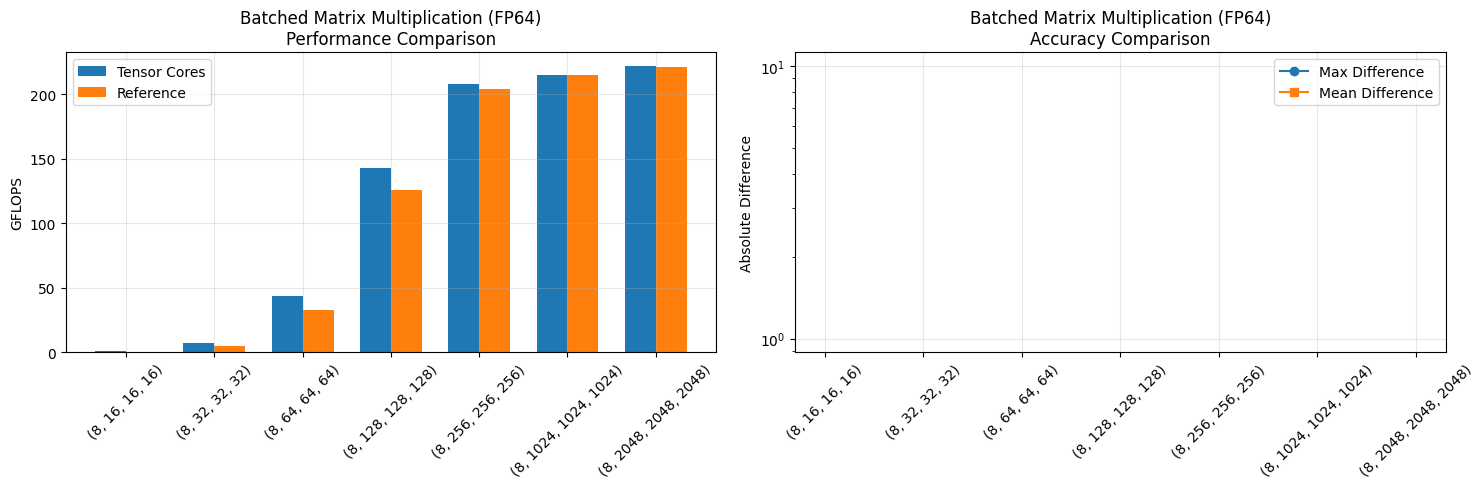

In [8]:
def test_batched_matmul_fp64():
    """Benchmark FP64 batched matrix multiplication (high accuracy version)."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Batched Matrix Multiplication (FP64)"
    
    # Shapes to test (batch_size, m, k, n)
    shapes = [
        (8, 16, 16, 16),
        (8, 32, 32, 32),
        (8, 64, 64, 64),
        (8, 128, 128, 128),
        (8, 256, 256, 256),
        (8, 1024, 1024, 1024),
        (8, 2048, 2048, 2048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random batched matrices for matrix multiplication."""
        batch_size, m, k, n = shape
        
        # Create inputs in the format expected by tensor_ops.batched_matmul_fp64
        a = cp.asfortranarray(cp.random.random((batch_size, m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((batch_size, k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        return [a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for batched matrix multiplication."""
        batch_size, m, k, n = shape
        # Batched matrix multiplication requires 2*batch_size*M*N*K FLOPS
        return 2 * batch_size * m * n * k
    
    # Define tensor operation
    def tensor_op(a, b):
        return tensor_ops.batched_matmul_fp64(a, b)
    
    # Define reference operation (using cupy's batch matmul)
    def reference_op(a, b):
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

batched_matmul_fp64_results = test_batched_matmul_fp64()
cleanup()

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Vector-Matrix Multiplication...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Vector-Matrix Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.91     0.00e+00     0.00e+00
32                                   0.09            0.03         3.15     0.00e+00     0.00e+00
64                                   0.40            0.11         3.53     0.00e+00     0.00e+00
128                                  1.52            0.45         3.38     0.00e+00     0.00e+00
256                                  5.68     

/tmp/ipykernel_58143/1396024437.py:165: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


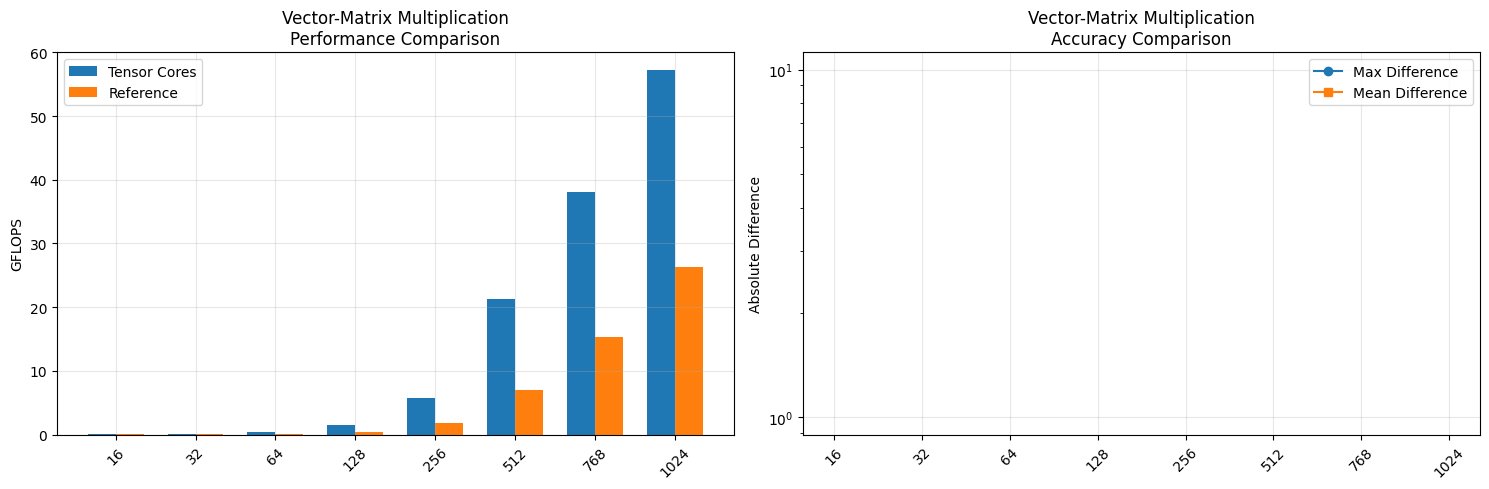

In [9]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_vector_matrix():
    """Benchmark vector-matrix multiplication (v*A) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Vector-Matrix Multiplication"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random vector and matrix in Fortran order."""
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for vector-matrix multiplication."""
        n = size
        # Vector-matrix multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Vector-matrix multiplication is v @ A
        return cp.matmul(v, a)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

vector_matrix_results = test_vector_matrix()
cleanup()

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Vector-Matrix Optimised Multiplication...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Vector-Matrix Optimised Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.90     0.00e+00     0.00e+00
32                                   0.10            0.03         3.60     0.00e+00     0.00e+00
64                                   0.40            0.11         3.58     0.00e+00     0.00e+00
128                                  1.56            0.44         3.54     0.00e+00     0.00e+00
256                       

/tmp/ipykernel_58143/1396024437.py:165: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


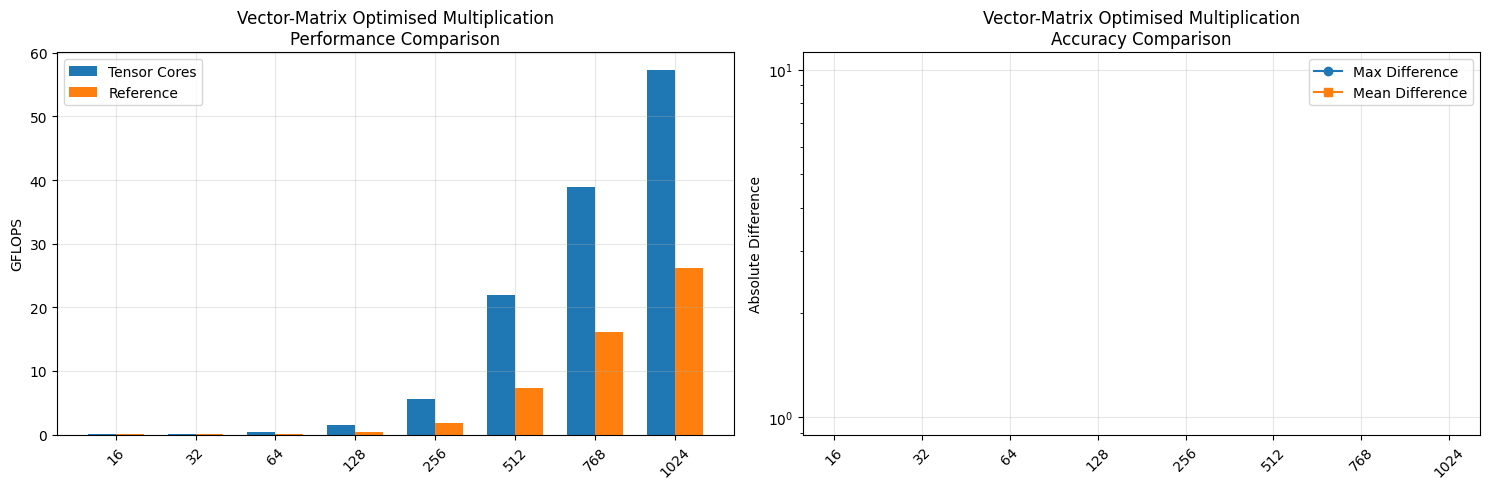

In [10]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_vector_matrix_optimised():
    """Benchmark optimised vector-matrix multiplication (v*A) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Vector-Matrix Optimised Multiplication"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random vector and matrix in Fortran order."""
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for vector-matrix multiplication."""
        n = size
        # Vector-matrix multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Vector-matrix multiplication is v @ A
        return cp.matmul(v, a)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

vector_matrix_optimised_results = test_vector_matrix_optimised()
cleanup()

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Matrix-Vector Multiplication...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Matrix-Vector Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.81     0.00e+00     0.00e+00
32                                   0.10            0.03         3.51     0.00e+00     0.00e+00
64                                   0.40            0.11         3.51     0.00e+00     0.00e+00
128                                  1.49            0.44         3.42     0.00e+00     0.00e+00
256                                  5.93     

/tmp/ipykernel_58143/1396024437.py:165: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


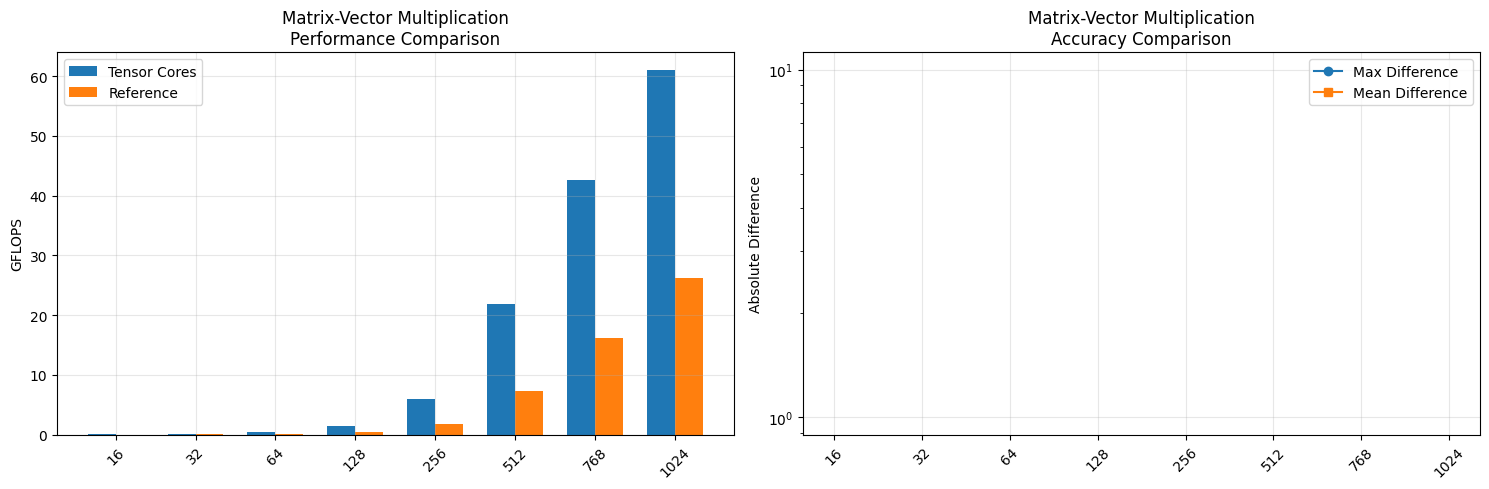

In [11]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_matrix_vector():
    """Benchmark matrix-vector multiplication (A*v) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Matrix-Vector Multiplication"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random matrix and vector in Fortran order."""
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(size) * 1.1)
        v /= (cp.sqrt(size) * 1.1)
        
        return [a, v]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for matrix-vector multiplication."""
        n = size
        # Matrix-vector multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(a, v):
        return tensor_ops.matmul_vector(a, v)
    
    # Define reference operation
    def reference_op(a, v):
        # Matrix-vector multiplication is A @ v
        return cp.matmul(a, v)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_vector_results = test_matrix_vector()
cleanup()

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Batched Vector Multiplication...
Warming up GPU...

Shape: (16, 10)

Shape: (32, 10)

Shape: (64, 10)

Shape: (128, 8)

Shape: (256, 4)

Shape: (512, 2)

Results for Batched Vector Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 10)                             0.05            0.01         8.98     3.33e-08     7.44e-09
(32, 10)                             0.21            0.02         8.74     3.39e-08     6.44e-09
(64, 10)                             0.84            0.10         8.71     4.85e-08     1.10e-08
(128, 8)                             2.65            0.39         6.78     3.92e-08     8.28e-09
(256, 4)                            

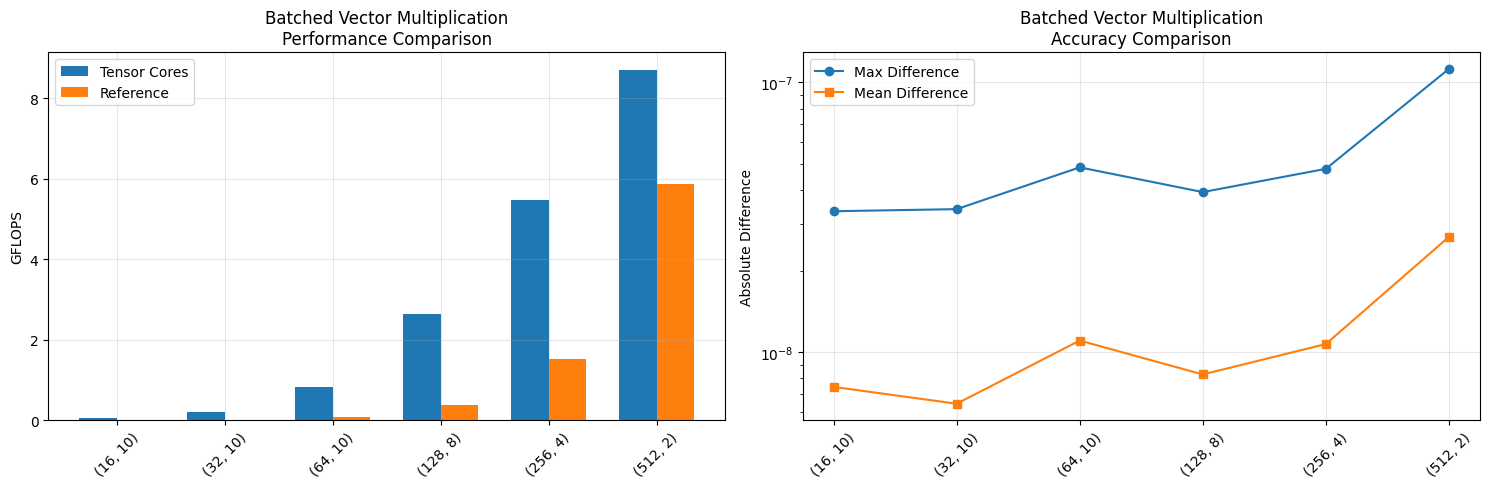

In [12]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_batched_vector():
    """Benchmark batched vector multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Batched Vector Multiplication"
    
    # Shapes to test (size, batch_size)
    shapes = [
        (16, 10),
        (32, 10),
        (64, 10),
        (128, 8),
        (256, 4),
        (512, 2)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random vectors and matrix in Fortran order."""
        size, batch_size = shape
        
        # Create batch of vectors (size, batch_size) in Fortran order
        v = cp.asfortranarray(cp.random.random((size, batch_size), dtype=cp.float64))
        
        # Create matrix (size, size) in Fortran order
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for batched vector multiplication."""
        size, batch_size = shape
        # Batched vector-matrix multiplication requires 2*size*size*batch_size FLOPS
        return 2 * size * size * batch_size
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.batched_vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Manual implementation of batched vector-matrix multiplication
        size, batch_size = v.shape
        result = cp.empty((batch_size, size), dtype=cp.float64)
        
        for i in range(batch_size):
            result[i] = cp.matmul(a, v[:, i])
            
        return result
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

batched_vector_results = test_batched_vector()
cleanup()

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Strided Batch Matrix Multiplication...
Warming up GPU...

Shape: (8, 16, 16, 16)

Shape: (8, 32, 32, 32)

Shape: (8, 64, 64, 64)

Shape: (8, 128, 128, 128)

Shape: (8, 256, 256, 256)

Shape: (8, 512, 512, 512)

Shape: (8, 1024, 1024, 1024)

Shape: (8, 2048, 2048, 2048)

Results for Strided Batch Matrix Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(8, 16, 16, 16)                      0.32            0.61         0.52     2.21e-01     5.17e-02
(8, 32, 32, 32)                      2.51            4.78         0.53     1.70e-01     3.77e-02
(8, 64, 64, 64)                     20.37           33.29         0.61     1.45e-01     2.64e-02
(8, 128, 1

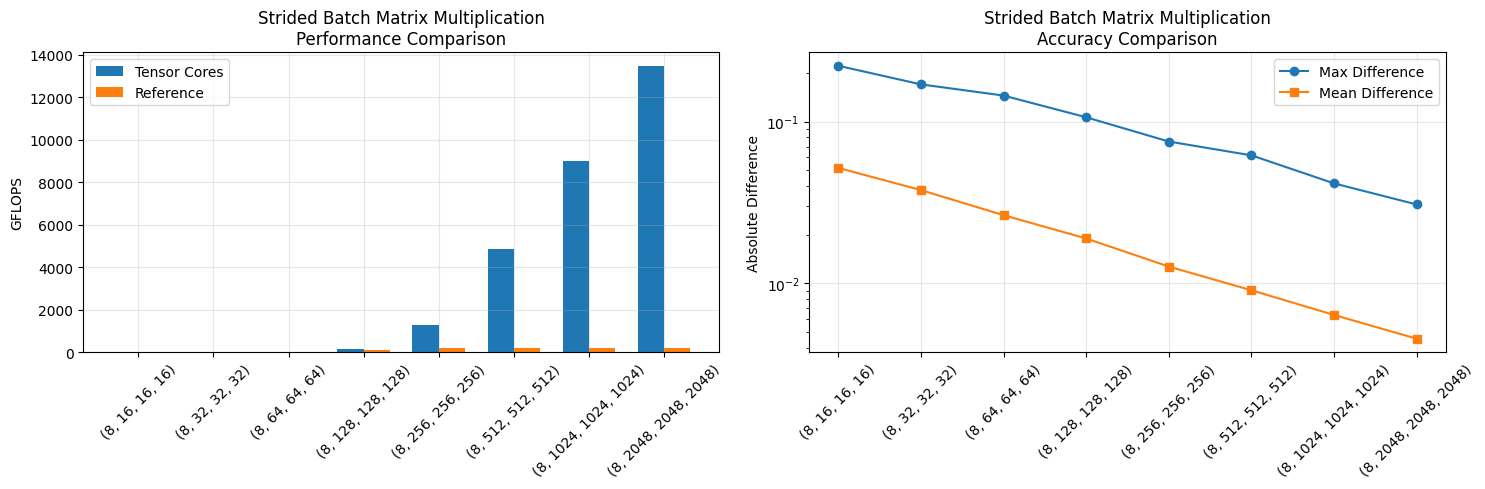

In [13]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_strided_batch():
    """Benchmark strided batch matrix multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Strided Batch Matrix Multiplication"
    
    # Shapes to test (batch_size, m, k, n)
    shapes = [
        (8, 16, 16, 16),
        (8, 32, 32, 32),
        (8, 64, 64, 64),
        (8, 128, 128, 128),
        (8, 256, 256, 256),
        (8, 512, 512, 512),
        (8, 1024, 1024, 1024),
        (8, 2048, 2048, 2048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random matrices for strided batch matrix multiplication."""
        batch_size, m, k, n = shape
        
        # Create inputs in the correct format and memory layout
        a = cp.asfortranarray(cp.random.random((batch_size, m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((batch_size, k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        # Prepare extra parameters needed for strided_batch_matmul
        return [m, k, n, batch_size, a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for strided batch matrix multiplication."""
        batch_size, m, k, n = shape
        # Strided batch matrix multiplication requires 2*batch_size*m*n*k FLOPS
        return 2 * batch_size * m * n * k
    
    # Define tensor operation
    def tensor_op(m, k, n, batch_size, a, b):
        return tensor_ops.strided_batch_matmul(m, k, n, batch_size, a, b)
    
    # Define reference operation
    def reference_op(m, k, n, batch_size, a, b):
        # Standard batch matmul for comparison
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

strided_batch_results = test_strided_batch()
cleanup()

In [14]:
def generate_summary_report(all_results):
    """Generate a summary report of all benchmark results from already-computed data."""
    print("\nSummary of All Benchmarks:")
    print(f"{'-' * 100}")
    print(f"{'Operation':30} {'Shape':20} {'Tensor GFLOPS':>15} {'Reference GFLOPS':>15} {'Speedup':>10} {'Max Diff':>10}")
    print(f"{'-' * 100}")
    
    for operation, results in all_results.items():
        for r in results:
            shape_str = str(r['shape'])
            print(f"{operation:30} {shape_str:20} {r['tensor_gflops']:15.2f} {r['reference_gflops']:15.2f} "
                  f"{r['speedup']:10.2f} {r['max_diff']:10.2e}")

# Collect already-computed results from individual test cells — no re-running
all_results = {
    "Matrix Power":                        matrix_power_results,
    "Improved Matmul32 (FP32 acc)":        improved_matmul32_results,
    "Improved Matmul64 (near-FP64)":       improved_matmul64_results,
    "Matrix Multiplication":               matrix_multiply_results,
    "Batched Matrix Multiplication":       batched_matmul_results,
    "Batched Matmul+Bias+ReLU (fused v5)": batched_matmul_fused_results,
    "Vector-Matrix Multiplication":        vector_matrix_results,
    "Matrix-Vector Multiplication":        matrix_vector_results,
    "Batched Vector Multiplication":       batched_vector_results,
    "Strided Batch Matrix Multiplication": strided_batch_results,
}

generate_summary_report(all_results)


Summary of All Benchmarks:
----------------------------------------------------------------------------------------------------
Operation                      Shape                  Tensor GFLOPS Reference GFLOPS    Speedup   Max Diff
----------------------------------------------------------------------------------------------------
Matrix Power                   (16, 16)                        0.28            0.18       1.57   1.98e-04
Matrix Power                   (32, 32)                        2.61            1.47       1.78   3.90e-04
Matrix Power                   (64, 64)                       20.23           10.52       1.92   4.66e-04
Matrix Power                   (128, 128)                    134.24           79.47       1.69   8.57e-04
Matrix Power                   (256, 256)                    860.50          179.18       4.80   9.87e-04
Matrix Power                   (512, 512)                   3024.90          260.70      11.60   2.00e-03
Matrix Power               

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Testing 4D Tensor Multiplication...

Shape: (2, 2, 16, 16)

Array shapes:
Input a: (2, 2, 16, 16)
Input b: (2, 2, 16, 16)
Output tensor: (2, 2, 16, 16)
Output cupy: (2, 2, 16, 16)

Shape: (4, 4, 32, 32)

Shape: (8, 8, 64, 64)

Shape: (8, 8, 128, 128)

Shape: (8, 8, 256, 256)

Shape: (8, 8, 512, 512)

Shape: (8, 8, 640, 640)

Detailed Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS     CuPy GFLOPS     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(2, 2, 16, 16)                       0.17            0.05     6.62e-05     1.42e-05
(4, 4, 32, 32)                       2.13            0.64     6.25e-05     1.23e-05
(8, 8, 64, 64)                      19.87            5.20     4.62e-05     7.69e-06
(8, 8, 128, 128)                   152.34           44.62     4.05e-05  

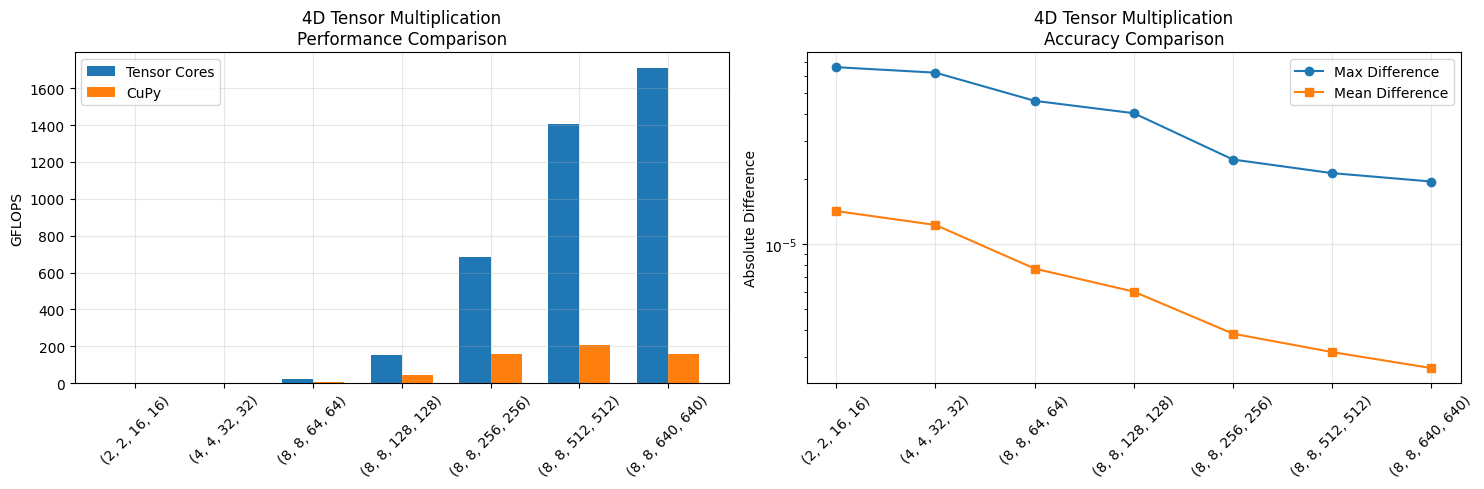

In [15]:
import numpy as np
import cupy as cp
import time
from tensor_matrix_ops import TensorMatrixOps
import matplotlib.pyplot as plt

# Cell for Tensor 4D Test
def test_tensor_4d():
    """Test 4D tensor multiplication with correct input format."""
    operation_name = "4D Tensor Multiplication"
    shapes = [
        (2, 2, 16, 16),     # (batch1, batch2, m, n)
        (4, 4, 32, 32),
        (8, 8, 64, 64),
        (8, 8, 128, 128),
        (8, 8, 256, 256),
        (8, 8, 512, 512),
        (8, 8, 640, 640)
    ]
    tensor_ops = TensorMatrixOps()
    
    print(f"\nTesting {operation_name}...")
    results = []
    
    for shape in shapes:
        print(f"\nShape: {shape}")
        try:
            batch1, batch2, m, n = shape
            
            # Create test data in format expected by tensor_4d_matmul
            a = cp.random.random((batch1, batch2, m, n), dtype=cp.float64)
            b = cp.random.random((batch1, batch2, n, n), dtype=cp.float64)
            
            # Scale inputs
            a /= (cp.sqrt(n) * 1.1)
            b /= (cp.sqrt(n) * 1.1)
            
            # Calculate FLOPS: regular matmul FLOPS * number of matmuls
            flops = 2 * m * n * n * batch1 * batch2
            
            # Time tensor core implementation
            tensor_times = []
            for i in range(3):
                cp.cuda.runtime.deviceSynchronize()
                start = time.perf_counter()
                c_tensor = tensor_ops.tensor_4d_matmul(a, b)
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                tensor_times.append(elapsed)
            
            # Time cupy implementation
            cupy_times = []
            for i in range(3):
                cp.cuda.runtime.deviceSynchronize()
                start = time.perf_counter()
                c_cupy = cp.empty((batch1, batch2, m, n), dtype=cp.float64)
                for i in range(batch1):
                    for j in range(batch2):
                        c_cupy[i,j] = cp.matmul(a[i,j], b[i,j])
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                cupy_times.append(elapsed)
            
            # Print shapes for verification
            if shape == shapes[0]:  # Only for first shape
                print("\nArray shapes:")
                print(f"Input a: {a.shape}")
                print(f"Input b: {b.shape}")
                print(f"Output tensor: {c_tensor.shape}")
                print(f"Output cupy: {c_cupy.shape}")
            
            # Compare results
            max_diff = cp.max(cp.abs(c_tensor - c_cupy))
            mean_diff = cp.mean(cp.abs(c_tensor - c_cupy))
            
            results.append({
                'shape': shape,
                'flops': flops,
                'tensor_times': tensor_times,
                'cupy_times': cupy_times,
                'tensor_gflops': flops / (min(tensor_times) * 1e9),
                'cupy_gflops': flops / (min(cupy_times) * 1e9),
                'max_diff': float(max_diff),
                'mean_diff': float(mean_diff),
                'sample_tensor': cp.asnumpy(c_tensor[0,0,:5,:5]),  # First batch, first 5x5 elements
                'sample_cupy': cp.asnumpy(c_cupy[0,0,:5,:5])      # First batch, first 5x5 elements
            })
            
            # Cleanup
            del a, b, c_tensor, c_cupy
            cp.cuda.runtime.deviceSynchronize()
            cp.get_default_memory_pool().free_all_blocks()
            
        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()
            
    if results:
        print("\nDetailed Comparison:")
        print("-" * 80)
        print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'CuPy GFLOPS':>15} {'Max Diff':>12} {'Mean Diff':>12}")
        print("-" * 80)
        
        for r in results:
            shape_str = str(r['shape'])
            print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['cupy_gflops']:15.2f} "
                  f"{r['max_diff']:12.2e} {r['mean_diff']:12.2e}")
        
        print("\nSample Output Comparison (first 5x5 slice):")
        print("-" * 80)
        for r in results:
            print(f"\nShape: {r['shape']}")
            print(f"Tensor:\n{r['sample_tensor']}")
            print(f"CuPy:\n{r['sample_cupy']}")
        
        # Create plots with operation name
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Performance comparison
        x = np.arange(len(results))
        width = 0.35
        
        tensor_gflops = [r['tensor_gflops'] for r in results]
        cupy_gflops = [r['cupy_gflops'] for r in results]
        
        ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
        ax1.bar(x + width/2, cupy_gflops, width, label='CuPy')
        ax1.set_ylabel('GFLOPS')
        ax1.set_title(f'{operation_name}\nPerformance Comparison')
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(r['shape']) for r in results], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Accuracy comparison
        max_diffs = [r['max_diff'] for r in results]
        mean_diffs = [r['mean_diff'] for r in results]
        
        ax2.plot(x, max_diffs, 'o-', label='Max Difference')
        ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
        ax2.set_ylabel('Absolute Difference')
        ax2.set_title(f'{operation_name}\nAccuracy Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(r['shape']) for r in results], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale('log')
        
        plt.tight_layout()
        plt.show()
    
    return results

# Run test
results = test_tensor_4d()

Initializing CUDA...
CUDA initialization complete
Function signatures configured
Shape                        Unfused ms   Fused ms   Speedup    CuPy ms
------------------------------------------------------------------------
fc1  (512x2048x128)             0.196ms    0.154ms     1.27x    1.824ms
fc2  (256x512x128)              0.127ms    0.080ms     1.59x    0.262ms
fc3  (10x256x128)               0.116ms    0.068ms     1.71x    0.125ms

                           vs CuPy FP64   vs unfused
fc1  (512x2048x128)            5.55e-02     7.73e-03
fc2  (256x512x128)             2.70e-02     3.73e-03
fc3  (10x256x128)              1.07e-05     1.76e-02

Note: vs_ref error is from TF32 rounding (same as batched_matmul), not from fusion.
      vs_unf measures the accuracy cost of applying bias+relu in TF32 vs FP64.


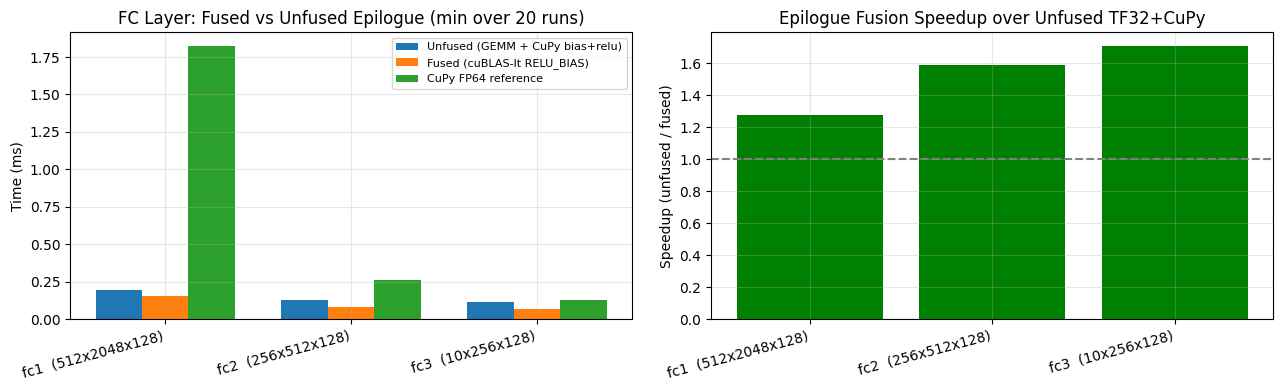

In [16]:
# ============================================================
# v5 Benchmark: cuBLAS-lt Epilogue Fusion
#
# Compares three approaches for GEMM + bias + relu at FC layer shapes:
#
#   unfused  — batched_matmul (pure TF32 GEMM) + separate CuPy bias+relu
#              Two global-memory passes: GEMM writes C, then bias/relu reads+writes C
#
#   fused    — batched_matmul_bias_relu (cuBLAS-lt CUBLASLT_EPILOGUE_RELU_BIAS)
#              One global-memory pass: bias+relu applied in registers
#              before the GEMM output is written to global memory
#
#   cupy_ref — cp.maximum(a @ b + bias[:, None], 0.0)  (pure CuPy, FP64 baseline)
#
# FC layer shapes tested:
#   fc1  M=512  K=2048 N=128  (largest, most bandwidth-sensitive)
#   fc2  M=256  K=512  N=128
#   fc3  M=10   K=256  N=128  (smallest)
# ============================================================

import numpy as np
import cupy as cp
import ctypes
import time
import matplotlib.pyplot as plt
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

REPEAT = 20   # timing repeats per measurement
WARMUP = 5    # discard first N runs

def _sync_time(fn, *args, repeat=REPEAT, warmup=WARMUP):
    """Time fn(*args) with GPU sync; return (result, min_ms, median_ms)."""
    times = []
    result = None
    for i in range(repeat + warmup):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        result = fn(*args)
        cp.cuda.Stream.null.synchronize()
        dt = (time.perf_counter() - t0) * 1e3  # ms
        if i >= warmup:
            times.append(dt)
    return result, min(times), float(np.median(times))

# FC layer shapes: (name, m, k, n, batch)
fc_shapes = [
    ("fc1  (512x2048x128)", 512, 2048, 128, 1),
    ("fc2  (256x512x128)",  256,  512, 128, 1),
    ("fc3  (10x256x128)",    10,  256, 128, 1),
]

print(f"{'Shape':<26} {'Unfused ms':>12} {'Fused ms':>10} {'Speedup':>9} {'CuPy ms':>10}")
print("-" * 72)

epilogue_results = []

for label, m, k, n, batch in fc_shapes:
    rng = cp.random.default_rng(42)
    A    = rng.standard_normal((batch, m, k), dtype=cp.float64)
    B    = rng.standard_normal((batch, k, n), dtype=cp.float64)
    bias = rng.standard_normal(m, dtype=cp.float64)

    # Unfused: pure GEMM then separate CuPy bias+relu
    def unfused(A, B, bias):
        C = ops.batched_matmul(A, B)
        C = C + bias[:, None]   # broadcast bias over n cols
        return cp.maximum(C, 0.0)

    # Fused: single cuBLAS-lt call (bias+relu in GEMM output registers)
    def fused(A, B, bias):
        return ops.batched_matmul_bias_relu(A, B, bias)

    # CuPy reference (FP64 matmul + bias + relu)
    def cupy_ref(A, B, bias):
        C = cp.matmul(A, B)
        C = C + bias[:, None]
        return cp.maximum(C, 0.0)

    res_unfused, t_unf_min, _ = _sync_time(unfused,  A, B, bias)
    res_fused,   t_fus_min, _ = _sync_time(fused,    A, B, bias)
    res_ref,     t_ref_min, _ = _sync_time(cupy_ref, A, B, bias)

    speedup = t_unf_min / t_fus_min

    # Correctness: fused (TF32) vs CuPy (FP64) — expect ~1e-4 from TF32 rounding
    max_err_vs_ref = float(cp.max(cp.abs(res_fused[0] - res_ref[0])))
    max_err_vs_unf = float(cp.max(cp.abs(res_fused[0] - res_unfused[0])))

    print(f"{label:<26} {t_unf_min:>10.3f}ms {t_fus_min:>8.3f}ms "
          f"{speedup:>8.2f}x {t_ref_min:>8.3f}ms")

    epilogue_results.append(dict(
        label=label, m=m, k=k, n=n, batch=batch,
        t_unfused=t_unf_min, t_fused=t_fus_min, t_cupy=t_ref_min,
        speedup=speedup, max_err_vs_ref=max_err_vs_ref, max_err_vs_unf=max_err_vs_unf,
    ))

    del A, B, bias, res_unfused, res_fused, res_ref
    cp.get_default_memory_pool().free_all_blocks()

print()
# max_err columns explained:
#   vs_ref  : fused (TF32 GEMM) vs CuPy (FP64 GEMM) — large because TF32 has
#             10-bit mantissa; for K=2048 this can be ~1e-2.  Not caused by fusion.
#   vs_unf  : fused vs unfused — both use TF32 for the GEMM; difference is
#             that unfused applies bias+relu in FP64 while fused does it in TF32.
#             Should be <1e-4 for all shapes.
print(f"{'':26} {'vs CuPy FP64':>12} {'vs unfused':>12}")
for r in epilogue_results:
    print(f"{r['label']:<26} {r['max_err_vs_ref']:>12.2e} {r['max_err_vs_unf']:>12.2e}")
print()
print("Note: vs_ref error is from TF32 rounding (same as batched_matmul), not from fusion.")
print("      vs_unf measures the accuracy cost of applying bias+relu in TF32 vs FP64.")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

labels  = [r["label"] for r in epilogue_results]
t_unf   = [r["t_unfused"] for r in epilogue_results]
t_fus   = [r["t_fused"]   for r in epilogue_results]
t_ref   = [r["t_cupy"]    for r in epilogue_results]
speedup = [r["speedup"]   for r in epilogue_results]

x = np.arange(len(labels))
w = 0.25
ax1.bar(x - w, t_unf, w, label="Unfused (GEMM + CuPy bias+relu)")
ax1.bar(x,     t_fus, w, label="Fused (cuBLAS-lt RELU_BIAS)")
ax1.bar(x + w, t_ref, w, label="CuPy FP64 reference")
ax1.set_ylabel("Time (ms)")
ax1.set_title("FC Layer: Fused vs Unfused Epilogue (min over 20 runs)")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha="right")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.bar(x, speedup, color="green")
ax2.axhline(1.0, color="gray", linestyle="--")
ax2.set_ylabel("Speedup (unfused / fused)")
ax2.set_title("Epilogue Fusion Speedup over Unfused TF32+CuPy")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha="right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Starting comparison...

Testing shape: (2, 2, 2, 16, 16)
Operations: 65,536
Initializing CUDA...
CUDA initialization complete
Function signatures configured
Running tensor core tests...
Tensor Run 1: 1.20ms (0.05 GFLOPS)
Tensor Run 2: 0.31ms (0.21 GFLOPS)
Tensor Run 3: 0.30ms (0.22 GFLOPS)
Tensor Run 4: 0.36ms (0.18 GFLOPS)
Tensor Run 5: 0.29ms (0.22 GFLOPS)
Running CuPy tests...

Matrix multiplication dimensions:
a_2d shape: (8, 16, 16)
b_2d shape: (8, 16, 16)
CuPy Run 1: 1.23ms (0.05 GFLOPS)
CuPy Run 2: 0.84ms (0.08 GFLOPS)
CuPy Run 3: 0.78ms (0.08 GFLOPS)
CuPy Run 4: 0.77ms (0.09 GFLOPS)
CuPy Run 5: 0.78ms (0.08 GFLOPS)
c_cupy shape: (2, 2, 2, 16, 16)
Computing differences...

Testing shape: (4, 4, 4, 32, 32)
Operations: 4,194,304
Initializing CUDA...
CUDA initialization complete
Function signatures configured
Running tensor core tests...
Tensor Run 1: 1.71ms (2.45 GFLOPS)
Tensor Run 2: 1.65ms (2.54 GFLOPS)
Tensor Run 3: 1.65ms (2.55 GFLOPS)
Tensor Run 4: 1.66ms (2.53 GFLOPS)
Tensor

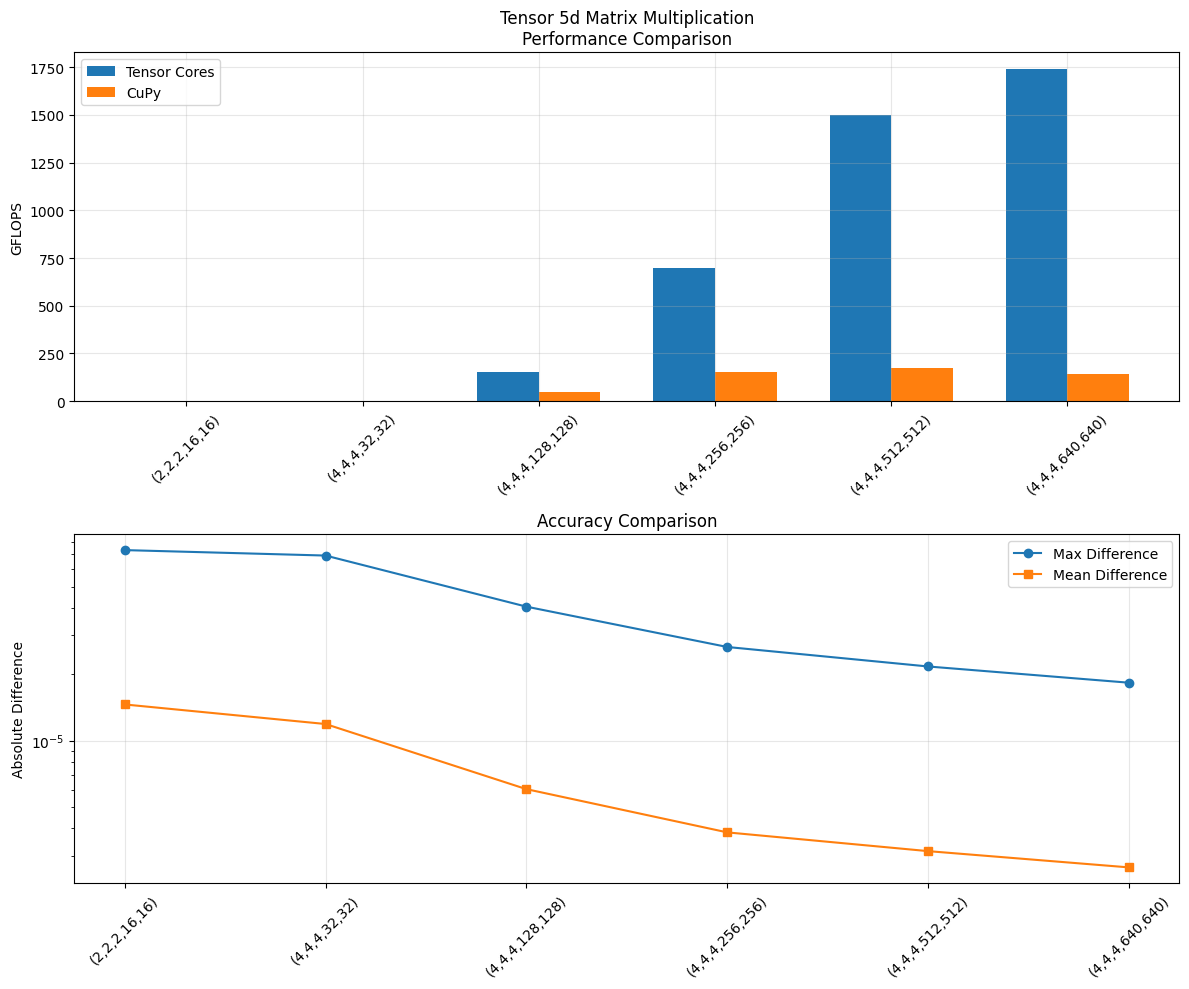


Detailed Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS     CuPy GFLOPS     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(2,2,2,16,16)                        0.22            0.09     7.31e-05     1.46e-05
(4,4,4,32,32)                        2.55            0.73     6.91e-05     1.19e-05
(4,4,4,128,128)                    151.38           47.60     4.05e-05     6.02e-06
(4,4,4,256,256)                    698.06          151.46     2.66e-05     3.83e-06
(4,4,4,512,512)                   1501.26          172.72     2.17e-05     3.15e-06
(4,4,4,640,640)                   1741.93          142.58     1.83e-05     2.66e-06

Sample Output Comparison (first 5 values):
--------------------------------------------------------------------------------

Shape: (2, 2, 2, 16, 16)
Tensor: [0.19987166 0.24774447 0.22010766 0.18067837 0.20032601]
CuPy:   [0.1

In [17]:
import numpy as np
import cupy as cp
import time
from tensor_matrix_ops import TensorMatrixOps
import matplotlib.pyplot as plt

def tensor_vs_cupy_comparison(shapes=None, num_runs=5, seed=42):  # Add a seed argument
    """Compare tensor core vs cupy implementation for performance and accuracy."""

    # Set the random seeds for reproducibility
    np.random.seed(seed)  # Set NumPy seed
    cp.random.seed(seed)  # Set CuPy seed

    # ... (rest of the function remains the same) ...
    # Default test shapes if none provided
    if shapes is None:
        # (batch, channels, depth, height, width)
        shapes = [
            (2, 2, 2, 16, 16),    
            (4, 4, 4, 32, 32),    
            (4, 4, 4, 128, 128),  
            (4, 4, 4, 256, 256), 
            (4, 4, 4, 512, 512),
            (4, 4, 4, 640, 640)
        ]

    results = []

    for shape in shapes:
        print(f"\nTesting shape: {shape}")
        batch_size, channels, depth, height, width = shape
        new_width = width  # For these tests.  Could be different.

        # Calculate theoretical operations
        flops = 2 * batch_size * channels * depth * height * width * new_width
        print(f"Operations: {flops:,}")

        try:
            # Initialize implementations
            tensor_ops = TensorMatrixOps()

            # Create test data (Fortran order)
            a = cp.random.random(shape, dtype=cp.float64)
            a = cp.asfortranarray(a)
            b = cp.random.random((batch_size, channels, depth, width, new_width), dtype=cp.float64)
            b = cp.asfortranarray(b)


            # Scale inputs to prevent overflow
            scale = cp.sqrt(width)
            a /= (scale * 1.1)
            b /= (scale * 1.1)

            # Time tensor core implementation
            tensor_times = []
            print("Running tensor core tests...")
            for i in range(num_runs):
                start = time.perf_counter()
                c_tensor = tensor_ops.tensor_5d_matmul(a, b)  # Pass a and b directly
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                tensor_times.append(elapsed)
                tensor_gflops = flops / (elapsed * 1e9)
                print(f"Tensor Run {i+1}: {elapsed*1000:.2f}ms ({tensor_gflops:.2f} GFLOPS)")


            # Time cupy implementation
            print("Running CuPy tests...")
            cupy_times = []
            # Reshape for cupy with correct dimensions
            a_2d = a.reshape(batch_size * channels * depth, height, width)
            b_2d = b.reshape(batch_size * channels * depth, width, new_width)

            print(f"\nMatrix multiplication dimensions:")
            print(f"a_2d shape: {a_2d.shape}")
            print(f"b_2d shape: {b_2d.shape}")

            for i in range(num_runs):
                start = time.perf_counter()
                c_cupy_reshaped = cp.zeros((batch_size * channels * depth, height, new_width), order='F', dtype=cp.float64)

                for j in range(batch_size * channels * depth):
                  c_cupy_reshaped[j,:,:] = cp.matmul(a_2d[j,:,:], b_2d[j,:,:])

                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                cupy_times.append(elapsed)
                cupy_gflops = flops / (elapsed * 1e9)
                print(f"CuPy Run {i+1}: {elapsed*1000:.2f}ms ({cupy_gflops:.2f} GFLOPS)")
            c_cupy = c_cupy_reshaped.reshape(batch_size, channels, depth, height, new_width)
            print(f"c_cupy shape: {c_cupy.shape}")


            # Compare results
            print("Computing differences...")
            max_diff = cp.max(cp.abs(c_tensor - c_cupy))
            mean_diff = cp.mean(cp.abs(c_tensor - c_cupy))
            std_diff = cp.std(cp.abs(c_tensor - c_cupy))

            # Store results
            results.append({
                'shape': shape,
                'flops': flops,
                'tensor_times': tensor_times,
                'cupy_times': cupy_times,
                'tensor_gflops': flops / (min(tensor_times) * 1e9),
                'cupy_gflops': flops / (min(cupy_times) * 1e9),
                'max_diff': float(max_diff),
                'mean_diff': float(mean_diff),
                'std_diff': float(std_diff),
                'sample_tensor': cp.asnumpy(c_tensor[0,0,0,0,:5]),
                'sample_cupy': cp.asnumpy(c_cupy[0,0,0,0,:5])
            })

            # Clean up GPU memory
            del a, b, c_tensor, c_cupy, a_2d, b_2d, c_cupy_reshaped
            cp.get_default_memory_pool().free_all_blocks()

        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()

    # Plot results if we have any
    if results:
        plot_comparison(results)

        # Print detailed comparison
        print("\nDetailed Comparison:")
        print("-" * 80)
        print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'CuPy GFLOPS':>15} {'Max Diff':>12} {'Mean Diff':>12}")
        print("-" * 80)

        for r in results:
            shape_str = f"({','.join(map(str, r['shape']))})"
            print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['cupy_gflops']:15.2f} "
                  f"{r['max_diff']:12.2e} {r['mean_diff']:12.2e}")

        print("\nSample Output Comparison (first 5 values):")
        print("-" * 80)
        for r in results:
            print(f"\nShape: {r['shape']}")
            print(f"Tensor: {r['sample_tensor']}")
            print(f"CuPy:   {r['sample_cupy']}")

    return results

def plot_comparison(results):
    """Create comparison plots for performance and accuracy."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Performance comparison
    shapes = [f"({','.join(map(str, r['shape']))})" for r in results]
    tensor_gflops = [r['tensor_gflops'] for r in results]
    cupy_gflops = [r['cupy_gflops'] for r in results]

    x = np.arange(len(shapes))
    width = 0.35
    operation_name="Tensor 5d Matrix Multiplication"

    ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
    ax1.bar(x + width/2, cupy_gflops, width, label='CuPy')
    ax1.set_ylabel('GFLOPS')
    ax1.set_title(f'{operation_name}\nPerformance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(shapes, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy comparison
    max_diffs = [r['max_diff'] for r in results]
    mean_diffs = [r['mean_diff'] for r in results]

    ax2.plot(x, max_diffs, 'o-', label='Max Difference')
    ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
    ax2.set_ylabel('Absolute Difference')
    ax2.set_title('Accuracy Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels(shapes, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Starting comparison...")
    try:
        results = tensor_vs_cupy_comparison() # Use default seed, or specify one
        # results = tensor_vs_cupy_comparison(seed=123)  # Example with a different seed
    except Exception as e:
        print(f"Test failed: {e}")

# it is CuPy that is running out of memory, not the tensor cores!